In [58]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv("cleaned_ecommerce_sales.csv")

df.head()

,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


## Dataset Inspection

The dataset is inspected to understand its structure, columns, data types,
and the information available for Machine Learning.

In [60]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (10000, 26)

Column names:
['Order_ID', 'Order_Date', 'Year', 'Month', 'Quarter', 'Season', 'Customer_ID', 'Customer_Gender', 'Customer_Segment', 'Region', 'Country', 'Category', 'Sub_Category', 'Product_Name', 'Unit_Price', 'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%', 'Shipping_Cost', 'Shipping_Method', 'Shipping_Days', 'Payment_Method', 'Order_Status']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  str    
 1   Order_Date        10000 non-null  str    
 2   Year              10000 non-null  int64  
 3   Month             10000 non-null  int64  
 4   Quarter           10000 non-null  str    
 5   Season            10000 non-null  str    
 6   Customer_ID       10000 non-null  str    
 7   Customer_Gender   10000 non-null  str    
 8   Custome

## Checking Missing Values

Before building the Machine Learning model, we check whether the dataset
contains missing values.

In [61]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Year                0
Month               0
Quarter             0
Season              0
Customer_ID         0
Customer_Gender     0
Customer_Segment    0
Region              0
Country             0
Category            0
Sub_Category        0
Product_Name        0
Unit_Price          0
Quantity            0
Discount            0
Revenue             0
Cost                0
Profit              0
Profit_Margin_%     0
Shipping_Cost       0
Shipping_Method     0
Shipping_Days       0
Payment_Method      0
Order_Status        0
dtype: int64

## Target Variable

The original `Order_Status` column contains multiple categories.

We will convert it into a binary classification target:

- 1 = Delivered
- 0 = Not Delivered

In [62]:
df["Is_Delivered"] = (df["Order_Status"] == "Delivered").astype(int)

df["Is_Delivered"].value_counts()

Is_Delivered
1    6273
0    3727
Name: count, dtype: int64

In [63]:
print("Target variable:", "Is_Delivered")
print("\nTarget classes:")
print(df["Is_Delivered"].value_counts())

print("\nNumber of unique target classes:")
print(df["Is_Delivered"].nunique())

Target variable: Is_Delivered

Target classes:
Is_Delivered
1    6273
0    3727
Name: count, dtype: int64

Number of unique target classes:
2


## Separating Features X and Target y

`X` contains the independent variables, also called input features.

`y` contains the dependent variable, also called the target variable.

In this project:

- X = input features used to make predictions
- y = Is_Delivered, the variable we want to predict

In [64]:
X = df.drop(columns=["Order_Status", "Is_Delivered"])
y = df["Is_Delivered"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 25)
y shape: (10000,)


## Preparing Input Features

Some columns are identifiers or have very high cardinality and are not
useful for this baseline model.

They are removed to keep the baseline Logistic Regression model practical.

In [65]:
X = X.drop(
    columns=["Order_ID", "Customer_ID", "Order_Date", "Product_Name"],
    errors="ignore"
)

print("X shape after removing identifier/high-cardinality columns:", X.shape)

X shape after removing identifier/high-cardinality columns: (10000, 21)


## Train-Test Split

The dataset is divided into two parts:

- 80% for training
- 20% for testing

The model will learn only from the training data.

The test data will remain unseen until prediction and evaluation.

`random_state=42` is used to make the split reproducible.

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train:

 (8000, 21)
X_test: (2000, 21)
y_train: (8000,)
y_test: (2000,)


## Identifying Feature Types

Categorical features contain categories such as gender, region, category,
payment method, and shipping method.

Numerical features contain values such as price, quantity, revenue, cost,
profit, and shipping days.

In [67]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Quarter', 'Season', 'Customer_Gender', 'Customer_Segment', 'Region', 'Country', 'Category', 'Sub_Category', 'Shipping_Method', 'Payment_Method']

Numerical features:
['Year', 'Month', 'Unit_Price', 'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%', 'Shipping_Cost', 'Shipping_Days']


C:\Users\usman\AppData\Local\Temp\ipykernel_21724\2017450614.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


## One-Hot Encoding

Machine Learning algorithms require numerical input.

One-Hot Encoding converts categorical variables into numerical columns.

To prevent data leakage, the encoder is fitted only on the training data
and then used to transform both training and testing data.

In [68]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [69]:
X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (8000, 77)
Encoded testing shape: (2000, 77)


## Feature Scaling

Feature scaling helps Logistic Regression work more effectively when
numerical features have different ranges.

The scaler is fitted only on the training data and then applied to the
testing data.

`with_mean=False` is used because One-Hot Encoding produces a sparse matrix.

In [70]:
scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (8000, 77)
Scaled testing shape: (2000, 77)


## Logistic Regression Model

Logistic Regression is a supervised Machine Learning algorithm commonly
used for binary classification.

In this project, it is used to predict whether an order was delivered
or not.

In [71]:
model = LogisticRegression(
    max_iter=10000,
    solver="liblinear",
    random_state=42
)

print(model)

LogisticRegression(max_iter=10000, random_state=42, solver='liblinear')


## Model Training

The Logistic Regression model is trained only on the training dataset.

The model does not see the testing data during training.

In [72]:
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## Making Predictions

After training, the model is used to make predictions on the unseen
testing dataset.

In [73]:
y_pred = model.predict(X_test_scaled)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[1 1 1 1 1 1 1 1 1 1]


## Model Accuracy

Accuracy measures the proportion of test observations that were correctly
classified by the model.

The accuracy is calculated using the predictions from the unseen test
dataset.

In [74]:
accuracy = accuracy_score(y_test, y_pred)

print("Baseline Logistic Regression Accuracy:", accuracy)
print(
    "Baseline Logistic Regression Accuracy (%):",
    round(accuracy * 100, 2),
    "%"
)

Baseline Logistic Regression Accuracy: 0.6275
Baseline Logistic Regression Accuracy (%): 62.75 %


## Confusion Matrix

A confusion matrix shows how many observations were correctly and
incorrectly classified for each class.

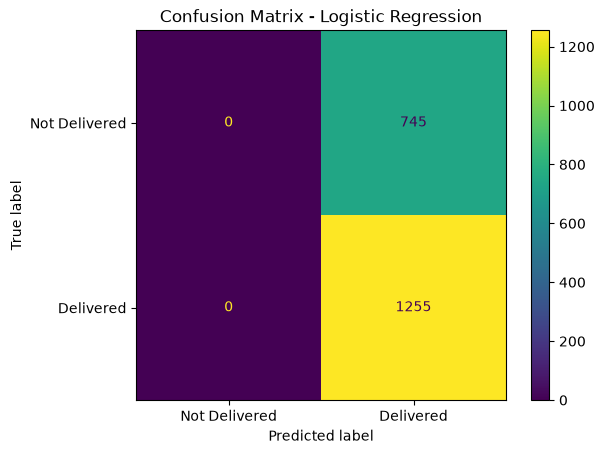

In [75]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Delivered", "Delivered"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Train-Test Data Summary

The following information confirms that the model was trained using 80%
of the data and evaluated using the remaining 20%.

In [76]:
print("Total samples:", len(X))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining percentage:", round(len(X_train) / len(X) * 100, 2), "%")
print("Testing percentage:", round(len(X_test) / len(X) * 100, 2), "%")

Total samples: 10000
Training samples: 8000
Testing samples: 2000

Training percentage: 80.0 %
Testing percentage: 20.0 %


## Data Leakage

Data leakage occurs when information from the testing data is allowed to
influence the training process.

In this project, the train-test split was performed before fitting the
encoder and scaler.

The encoder and scaler were fitted only on the training data and then
applied to the testing data.

The Logistic Regression model was also trained only on `X_train` and
`y_train`.

This helps ensure that the test data remains unseen during training.

Evaluating a model on the same data used for training can produce
overly optimistic results because the model has already seen that data.

In [77]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully.")

Random Forest imported successfully.


In [78]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print(rf_model)

RandomForestClassifier(random_state=42)


In [79]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['Quarter', 'Season', 'Customer_Gender', 'Customer_Segment', 'Region', 'Country', 'Category', 'Sub_Category', 'Shipping_Method', 'Payment_Method']

Numerical columns:
['Year', 'Month', 'Unit_Price', 'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%', 'Shipping_Cost', 'Shipping_Days']


C:\Users\usman\AppData\Local\Temp\ipykernel_21724\2143377955.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


In [80]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        ),
        (
            "numerical",
            "passthrough",
            numerical_cols
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [81]:
X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

print("Encoding completed successfully.")
print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape :", X_test_encoded.shape)

Encoding completed successfully.
X_train_encoded shape: (8000, 77)
X_test_encoded shape : (2000, 77)


In [82]:
rf_model.fit(
    X_train_encoded,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [83]:
y_pred_rf = rf_model.predict(X_test_encoded)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_rf))

Predictions generated successfully.
Number of predictions: 2000


In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Evaluation metrics imported successfully.")

Evaluation metrics imported successfully.


In [85]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

print("===== RANDOM FOREST RESULTS =====")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")

===== RANDOM FOREST RESULTS =====
Accuracy : 0.6085
Precision: 0.5248
Recall   : 0.6085
F1-Score : 0.5094


In [86]:
from sklearn.metrics import classification_report

print("===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.35      0.06      0.11       745
           1       0.63      0.93      0.75      1255

    accuracy                           0.61      2000
   macro avg       0.49      0.50      0.43      2000
weighted avg       0.52      0.61      0.51      2000



In [87]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("===== CONFUSION MATRIX =====")
print(cm_rf)

===== CONFUSION MATRIX =====
[[  46  699]
 [  84 1171]]


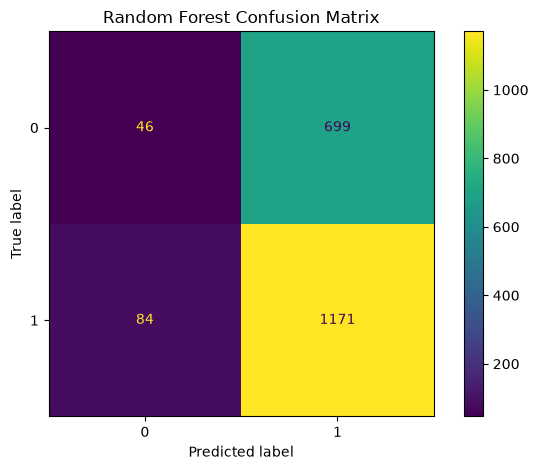

In [88]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [89]:
print("===== PREDICTION VARIABLES =====")

for name in list(globals()):
    if name.startswith("y_pred"):
        print(name)

===== PREDICTION VARIABLES =====
y_pred
y_pred_rf


In [90]:
# Find prediction variables from Day 6
baseline_candidates = [
    name
    for name in list(globals())
    if name.startswith("y_pred") and name != "y_pred_rf"
]

print("Possible baseline prediction variables:")
print(baseline_candidates)

if len(baseline_candidates) == 0:
    raise NameError(
        "No Day 6 baseline prediction variable was found. "
        "Go back to Day 6 and run the baseline model prediction cell."
    )

elif len(baseline_candidates) > 1:
    raise ValueError(
        f"More than one possible baseline prediction variable found: "
        f"{baseline_candidates}. We need to identify the correct Day 6 baseline."
    )

else:
    baseline_predictions = globals()[baseline_candidates[0]]
    print(
        f"Using '{baseline_candidates[0]}' as the Day 6 baseline predictions."
    )

Possible baseline prediction variables:
['y_pred']
Using 'y_pred' as the Day 6 baseline predictions.


In [91]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions,
    average="weighted",
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    average="weighted",
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    average="weighted",
    zero_division=0
)

print("===== BASELINE RESULTS =====")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-Score : {baseline_f1:.4f}")

===== BASELINE RESULTS =====
Accuracy : 0.6275
Precision: 0.3938
Recall   : 0.6275
F1-Score : 0.4839


In [92]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Model",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        accuracy_rf
    ],
    "Precision": [
        baseline_precision,
        precision_rf
    ],
    "Recall": [
        baseline_recall,
        recall_rf
    ],
    "F1-Score": [
        baseline_f1,
        f1_rf
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline Model,0.6275,0.393756,0.6275,0.483879
1,Random Forest,0.6085,0.524750,0.6085,0.509439


In [93]:
import joblib

model_package = {
    "preprocessor": preprocessor,
    "model": rf_model
}

joblib.dump(
    model_package,
    "random_forest_model.pkl"
)

print("Random Forest model saved successfully.")
print("File: random_forest_model.pkl")

Random Forest model saved successfully.
File: random_forest_model.pkl


In [94]:
import os

print(
    "Model file exists:",
    os.path.exists("random_forest_model.pkl")
)

Model file exists: True


## Random Forest

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to make a final prediction.

In this project, the Random Forest was initialized with `n_estimators=100` and `random_state=42`.

Instead of relying on one Decision Tree, Random Forest combines the predictions of many trees. This ensemble approach can make predictions more robust and can help the model learn nonlinear relationships in tabular data.

The model was trained using the existing training partition and evaluated on the unseen testing partition.

## Linear Models vs Decision Trees

Linear models assume that the relationship between input features and the prediction can be represented using a linear equation or linear combination of features.

Decision Trees use a sequence of feature-based decision rules to divide the data into different regions. This allows them to model nonlinear relationships that a simple linear model may not capture effectively.

Random Forest extends the Decision Tree approach by combining many trees into an ensemble, providing a more robust nonlinear modelling approach.

## Evaluation Metrics

The Random Forest model was evaluated using Accuracy, Precision, Recall, and F1-Score.

Accuracy represents the overall proportion of correct predictions.

Precision measures how many predicted class instances were actually correct.

Recall measures how many actual class instances were correctly identified.

F1-Score combines Precision and Recall using their harmonic mean:

F1 = 2 × (Precision × Recall) / (Precision + Recall)

F1-Score is emphasized because Accuracy alone may not fully represent model performance, particularly when the class distribution is imbalanced.

## Random Forest Results

The Random Forest model produced the following results on the testing dataset:

- Accuracy: **60.85%**
- Precision: **52.48%**
- Recall: **60.85%**
- F1-Score: **50.94%**

The results show that Accuracy alone does not tell the complete story of model performance. The lower F1-Score indicates that Precision and Recall should also be considered when evaluating this classification model.

## Confusion Matrix

The confusion matrix was used to visualize the classification results.

The matrix shows the relationship between the actual class labels and the predicted class labels, making it possible to observe correct classifications and classification errors for each class.

For the Random Forest model, the confusion matrix was:

[[46, 699],
 [84, 1171]]

## Conclusion

The Random Forest Classifier was successfully trained using the existing Day 6 training split and evaluated on the unseen testing split.

The model used 100 Decision Trees with `random_state=42` and was evaluated using Accuracy, Precision, Recall, F1-Score, Classification Report, and a Confusion Matrix.

The Random Forest achieved an Accuracy of 60.85%, Precision of 52.48%, Recall of 60.85%, and F1-Score of 50.94%.

The model was compared with the previous baseline model using the same evaluation metrics. The comparison should be interpreted using F1-Score as well as the other classification metrics rather than Accuracy alone.